## Load python libraries

In [1]:
# Import the main PyTorch package
import torch

# Import submodules: nn: neural network, optim: optimization algorithms
from torch import nn, optim

# Import classes to manipulate datasets and tensors
from torch.utils.data import TensorDataset, DataLoader
# import the activation function
from torch.nn import BCEWithLogitsLoss

In [2]:
!pip install torchtext

## import text based libraries

In [3]:
import torchtext

from torchtext.vocab import Vocab

from torchtext.data.utils import get_tokenizer

from torchtext.vocab import GloVe

In [6]:
# Read the review dataset and output the first five rows
import pandas as pd
df = pd.read_csv("/content/NLP-REVIEW-DATA-CLASSIFICATION-TRAINING.csv")
df.head()


,ID,reviewText,summary,verified,time,log_votes,isPositive
0,65886,Purchased as a quick fix for a needed Server 2...,"Easy install, seamless migration",True,1458864000,0.000000,1
1,19822,So far so good. Installation was simple. And r...,Five Stars,True,1417478400,0.000000,1
2,14558,Microsoft keeps making Visual Studio better. I...,This is the best development tool I've ever used.,False,1252886400,0.000000,1
3,39708,Very good product.,Very good product.,True,1458604800,0.000000,1
4,8015,So very different from my last version and I a...,... from my last version and I am having a gre...,True,1454716800,2.197225,0


## Perform EDA

In [7]:
# Check for imbalanced labels
df["isPositive"].value_counts()

# Identify missing values
print(df.isna().sum())

# Fill in missing values
df["reviewText"] = df["reviewText"].fillna("missing")
print(df.isna().sum())

ID             0
reviewText    10
summary       12
verified       0
time           0
log_votes      0
isPositive     0
dtype: int64
ID             0
reviewText     0
summary       12
verified       0
time           0
log_votes      0
isPositive     0
dtype: int64


## Split the training dataset

In [8]:
from sklearn.model_selection import train_test_split
# Separate 10% for the validation dataset
train_text, val_text, train_label, val_label = train_test_split(
	df["reviewText"].tolist(),
	df["isPositive"].tolist(),
	test_size = 0.10,
	shuffle = True,
	random_state = 324
)

#Transforming the text

In [9]:
!pip install d2l

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 53.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 98.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.3/98.3 kB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.4/345.4 kB 43.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.5/93.5 kB 15.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.4
    Uninstalling scipy-1.11.4:
      Successfully uninstalled scipy-1.11.4
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 3.1.1
    Uninstalling pyparsing-3.1.1:


In [10]:
from collections import Counter
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import vocab
# Use get_tokenizer to extract tokens from the text
# Use Vocab to create a vocabulary with the tokens
# tokenizer = get_tokenizer("basic_english")
# counter = Counter()
# for line in train_text:
# 	counter.update(tokenizer(line))
# vocab = vocab(counter, min_freq = 2) # min_freq>1 for skipping misspelled words


In [11]:
tokenizer = get_tokenizer("basic_english")
counter = Counter()
for line in train_text:
    counter.update(tokenizer(line))
vocab = vocab(counter, min_freq = 2, specials = ["<unk>"]) #min_freq>1 for skipping misspelled words
vocab.set_default_index(vocab['<unk>'])

In [12]:
# Print examples
print(f"'home' -> {vocab['home']}")
print(f"'wash' -> {vocab['wash']}")
# unknown word (assume from test set)
print(f"'hjk' -> {vocab['hjj']}")


'home' -> 666
'wash' -> 17661
'hjk' -> 0


In [13]:
print("The size of the voccabulary",len(vocab))

The size of the voccabulary 26300


In [14]:
print(vocab.get_itos()[0:25])

['<unk>', 'worked', 'great', '!', 'i', "'", 've', 'been', 'using', 'turbo', 'tax', 'for', 'at', 'least', 'ten', 'years', 'and', 'have', 'loved', 'it', 'from', 'the', 'start', '.', 'this']


In [15]:
for token in tokenizer(train_text[101]):
  print(token,vocab[token])

this 24
is 60
a 66
fast 1270
and 16
simple 468
way 44
to 74
do 228
taxes 29
. 23
you 40
are 483
able 395
to 74
import 1529
information 303
from 20
your 28
financial 601
institutions 1537
. 23
if 293
your 28
company 89
provides 934
it 19
, 49
you 40
can 41
import 1529
your 28
w2s 1913
. 23
i 4
use 59
this 24
annually 1914
and 16
i 4
love 39
it 19
. 23


## Transforming the text to token

In [16]:
# Create a mapper to transform the text data
text_transform_pipeline = lambda x: [vocab[token] for token in tokenizer(x)]

# Display results
print(f"Before transform:\t{train_text[101]}")
print(f"After transform:\t{text_transform_pipeline(train_text[101])}")


Before transform:	This is a fast and simple way to do taxes. You are able to import information from your financial institutions. If your company provides it, you can import your W2s. I use this annually and I love it.
After transform:	[24, 60, 66, 1270, 16, 468, 44, 74, 228, 29, 23, 40, 483, 395, 74, 1529, 303, 20, 28, 601, 1537, 23, 293, 28, 89, 934, 19, 49, 40, 41, 1529, 28, 1913, 23, 4, 59, 24, 1914, 16, 4, 39, 19, 23]


## normalize the text length

In [17]:
# Use the dictionary to tokenize each review in reviews_split
# Store the tokenized reviews in reviews_ints
import numpy as np
def pad_features(reviews_split, seq_length):
  reviews_ints = []
  for review in reviews_split:
    reviews_ints.append(text_transform_pipeline(review))
  # Get the correct rows x columns shape
  features = np.ones((len(reviews_ints), seq_length), dtype=int)

  # For each review, grab that review
  for i, row in enumerate(reviews_ints):
    features[i, -len(row):] = np.array(row)[:seq_length]

  return torch.tensor(features, dtype=torch.int64)


In [18]:
for text in train_text[9:11]:
  print(f"Text: {text}\n")
  print(f"Original length of the text: {len(text)}\n")
  tt = pad_features([text], seq_length = 50)
  print(f"Transformed text: \n{tt}\n")
  print(f"Shape of transformed text: {tt.shape}\n")


Text: Didnt give a 5 because I don't know what I need. I like it great

Original length of the text: 64

Transformed text: 
tensor([[  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1, 278, 279,  66, 280, 281,   4, 240,   5, 128, 282,
         283,   4, 284,  23,   4,  45,  19,   2]])

Shape of transformed text: torch.Size([1, 50])

Text: I downloaded the 30 day trial onto my wife's Mac about a week ago, but I don't know if I did it correctly as she is still getting spam..but not quite as much. Perhaps someone has information on this as I don't find a way to send an email to the company to see if I am in the trial period.

Original length of the text: 288

Transformed text: 
tensor([[  4, 285,  21, 286, 273, 287, 288, 206, 289,   5, 262, 290, 148,  66,
         291, 292,  49,  68,   4, 240,   5, 128, 282, 293,   4, 119,  19, 294,
          30, 295,  60, 296, 297

## Create tensor

In [19]:
#vocab.append_token('stragedy')
#vocab.append_token('promblems')
#vocab.append_token('fvs8')
#vocab.append_token('years-very')
#vocab.append_token('bloop')
#vocab.append_token('it-no')

In [20]:
max_len = 50
batch_size = 64

# Pass transformed and padded data to dataset
# Create data loaders
train_dataset = TensorDataset(
    pad_features(train_text, max_len),
    torch.tensor(train_label)
)
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          drop_last=True)

val_dataset = TensorDataset(pad_features(val_text, max_len),
                            torch.tensor(val_label))
val_loader = DataLoader(val_dataset,
                        batch_size=batch_size,
                        drop_last=True)

In [35]:
train_dataset.tensors[0].shape

torch.Size([50400, 50])

## Embedding vector using Glove

In [21]:
from torchtext.vocab import GloVe
GloVe.url['6B'] = 'https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip'
glove = GloVe(name="6B", dim = 300)
embedding_matrix = glove.get_vecs_by_tokens(vocab.get_itos())


.vector_cache/glove.6B.zip: 862MB [00:25, 34.5MB/s]                           
100%|█████████▉| 400000/400001 [00:53<00:00, 7519.74it/s]


In [27]:
embedding_matrix.shape

torch.Size([26300, 300])

In [36]:
embedding_matrix[0]

tensor([ 0.4292, -0.2969,  0.1501,  0.2452, -0.0035, -0.0577,  0.1409, -0.2223,
         0.2212,  0.7672, -0.0773, -0.0711,  0.0629, -0.2202, -0.1082, -0.3014,
         0.2322,  0.1687, -0.0045,  0.1683, -0.0579, -0.0363, -0.2735, -0.1630,
         0.2394, -0.0119,  0.0447,  0.1053,  0.1029, -0.0233, -0.0114, -0.3817,
         0.0612,  0.0171,  0.4155, -0.1091,  0.0960,  0.1915, -0.0075, -0.1946,
        -0.0432,  0.2598,  0.0053, -0.1836,  0.2252, -0.0188, -0.1582, -0.5869,
         0.2493, -0.1303, -0.0537,  0.0316, -0.1856,  0.0610, -0.0851, -0.0965,
         0.2786, -0.2473, -0.1539,  0.0418,  0.0704, -0.0623, -0.2849,  0.0152,
         0.1440,  0.3359, -0.2883, -0.0025, -0.0876, -0.0574,  0.0067, -0.0753,
        -0.0678, -0.0566,  0.1930,  0.0250, -0.3919, -0.1593,  0.2612,  0.1022,
         0.0877,  0.0433, -0.1798, -0.1897,  0.0511, -0.0164, -0.0071, -0.3277,
        -0.2075, -0.0213,  0.1167, -0.0676,  0.2681,  0.0962,  0.0516, -0.0365,
         0.3172, -0.1589, -0.0555,  0.28

In [37]:
# Function to find similar words
def find_similar_words(embedding, word, n=10):
    # Ensure the word is in the vocabulary
    if word not in embedding.stoi:
        raise ValueError(f"{word} not in vocabulary")

    # Get the embedding vector for the word
    word_vec = embedding.vectors[embedding.stoi[word]].unsqueeze(0)

    # Compute cosine similarity between word_vec and all other word vectors
    # cosine_similarity = (A * B) / (||A||*||B||)
    cos_sim = torch.mm(word_vec, embedding.vectors.t()) / (torch.norm(word_vec, dim=1) * torch.norm(embedding.vectors, dim=1).unsqueeze(0))

    # Get the indices of the top n similar words (excluding the word itself)
    _, indices = torch.topk(cos_sim, n + 1, largest=True)
    indices = indices.squeeze().tolist()[1:]  # Exclude the word itself

    # Retrieve the similar words
    similar_words = [embedding.itos[idx] for idx in indices]

    return similar_words

find_similar_words(glove, "good", n=5)

['better', 'really', 'always', 'you', 'well']

In [39]:
find_similar_words(glove, "information", n=20)

['data',
 'knowledge',
 'provide',
 'provided',
 'documents',
 'access',
 'providing',
 'available',
 'relevant',
 'intelligence',
 'details',
 'reports',
 'obtain',
 'specific',
 'database',
 'provides',
 'detailed',
 'web',
 'internet',
 'useful']

In [1]:
import torch
from torchtext.vocab import GloVe, vocab
from collections import Counter

# Define a simple list of words to simulate a vocabulary from your dataset
sample_vocab = ["hello", "world", "python", "programming", "data", "science"]

# Create a counter object for the vocabulary
counter = Counter(sample_vocab)

# Create a vocabulary object
vocabulary = vocab(counter)

# Load GloVe embeddings
glove = GloVe(name="6B", dim=50)  # Using 50-dimensional embeddings for simplicity

# Function to prepare the embedding matrix
def prepare_embedding_matrix(glove_model, vocabulary):
    embedding_matrix = []

    # For each unique word in your vocabulary
    for word in vocabulary.get_itos():
        if word in glove_model.stoi:
            # If the word is in the GloVe vocabulary, get its embedding
            embedding_matrix.append(glove_model.vectors[glove_model.stoi[word]])
        else:
            # If the word is not in the GloVe vocabulary, initialize a random vector (for unknown words)
            embedding_matrix.append(torch.randn(glove_model.dim))

    # Stack all vectors to create the embedding matrix
    embedding_matrix = torch.stack(embedding_matrix)

    return embedding_matrix

# Prepare the embedding matrix
embedding_matrix = prepare_embedding_matrix(glove, vocabulary)

# Example: Get the embedding for the word "python"
word_idx = vocabulary["python"]  # Get the index of "python" in your vocabulary
python_embedding = embedding_matrix[word_idx]  # Retrieve the embedding

print(f"Embedding for 'python':\n{python_embedding}")


.vector_cache/glove.6B.zip: 862MB [02:39, 5.40MB/s]                           
100%|█████████▉| 399999/400000 [00:15<00:00, 25709.28it/s]


Embedding for 'python':
tensor([ 0.5897, -0.5504, -1.0106,  0.4123,  0.5735,  0.2346, -0.3577, -1.7800,
         0.1075,  0.7491,  0.4501,  1.0351,  0.4835,  0.4795,  0.5191, -0.1505,
         0.3247,  1.0789, -0.9089,  0.4294, -0.5639,  0.6996,  0.1350,  0.1656,
        -0.0636,  0.3544,  0.4282,  0.1536, -0.4702, -1.0935,  1.3610, -0.8082,
        -0.6740,  1.2606,  0.2955,  1.0835,  0.2444, -1.1877, -0.6020, -0.0683,
         0.6626,  0.4534, -1.0178,  0.6827, -0.2079, -0.7339,  1.2597,  0.1542,
        -0.9326, -0.1503])


#Building Neural Network

In [ ]:
# Define RNN hyperparameters, size of the hidden state vectors
hidden_size = 128

# Define general neural network training hyperparameters
learning_rate = 0.0001
epochs = 15

# Define embedding vector and vocabulary size hyperparameters
embed_size = 300 # glove.6B.300d.txt
vocab_size = len(vocab.get_itos())

In [ ]:
class Net(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=1)
        self.rnn = nn.RNN(
            embed_size, hidden_size, num_layers=num_layers, batch_first=True
        )

        self.linear = nn.Linear(hidden_size, num_classes)

    def forward(self, inputs):
        embeddings = self.embedding(inputs)
        # Call the RNN layer
        outputs, _ = self.rnn(embeddings)

        # Output shape after RNN: (batch_size, max_len, hidden_size)
        # Get the output from the last time step with outputs[:, -1, :] below
        # The output shape becomes: (batch_size, 1, hidden_size)
        # Send it through the linear layer
        return self.linear(outputs[:, -1, :])

# Initialize the weights
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
    if type(m) == nn.RNN:
        for param in m._flat_weights_names:
            if "weight" in param:
                nn.init.xavier_uniform_(m._parameters[param])

#Initialize the model

In [ ]:
# Our architecture with 2 RNN layers
model = Net(vocab_size, embed_size, hidden_size,
            num_classes=2, num_layers=2)

# We set the embedding layer's parameters from GloVe
model.embedding.weight.data.copy_(embedding_matrix)
# We won't change/train the embedding layer
model.embedding.weight.requires_grad = False

# training the data

In [ ]:
from d2l import torch as d2l
def accuracy(y_hat, y):
    """Compute the number of correct predictions."""
    pred = torch.argmax(y_hat, axis=1)
    return torch.sum(pred == y)

def eval_accuracy(net, data_loader):
    # Use accumulator to keep track of metrics: correct predictions, num of predictions
    metric = d2l.Accumulator(2)

    net.eval()
    for X, y in data_loader:
        y_hat = net(X)
        metric.add(accuracy(y_hat, y), y.numel())

    return metric[0] / metric[1]

print("Classification Accuracy:", eval_accuracy(model, val_loader))

# Train the network
def train_net(net, train_loader, test_loader, num_epochs=1, lr=0.001):

    net.apply(init_weights)
    loss = nn.CrossEntropyLoss()
    trainer = torch.optim.SGD(net.parameters(), lr=lr)

    # Collect training times for each epoch
    train_times = []
    # Collect train losses after each epoch
    train_losses = []
    # Collect train and test accuracy
    train_accs, test_accs = [], []

    net.train()
    for epoch in range(num_epochs):
        train_loss = 0
        metric = d2l.Accumulator(3)

        timer = d2l.Timer()
        timer.start()
        # Training loop
        for X, y in train_loader:
            # Compute gradients and update parameters
            y_hat = net(X)
            l = loss(y_hat, y)
            trainer.zero_grad()
            l.backward()
            trainer.step()
            metric.add(l.item() * len(y), accuracy(y_hat, y), y.numel())
            train_loss, train_acc = metric[0]/metric[2], metric[1]/metric[2]
        timer.stop()

        # Store training times
        train_times.append(timer.sum())
        # Store the loss after one epoch of training
        train_losses.append(train_loss)
        # Store the train accuracy
        train_accs.append(train_acc)
        # Compute the test accuracy after one epoch
        test_acc = eval_accuracy(net, test_loader)
        test_accs.append(test_acc)

        print(f'epoch {epoch+1}, Train loss {train_loss:.4f}, Train accuracy {train_acc:.4f}, Val accuracy {test_acc:.4f},  Training time (s) {timer.sum():.4f}')

    return train_losses, train_accs, test_accs


Classification Accuracy: 0.48976293103448276


##Plot the loss and accuracy

In [ ]:

import matplotlib.pyplot as plt
# Plot the training losses
def plot_losses(train_losses, train_accs, test_accs):

    plt.plot(train_losses, label="Training Loss")
    plt.title("Loss values")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.plot(train_accs, "g", label="Train Accuracy")
    plt.plot(test_accs, "red", label="Validation Accuracy")
    plt.title("Accuracy values")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

epoch 1, Train loss 0.7175, Train accuracy 0.5779, Val accuracy 0.5982,  Training time (s) 33.9902
epoch 2, Train loss 0.6953, Train accuracy 0.5903, Val accuracy 0.6076,  Training time (s) 34.6641
epoch 3, Train loss 0.6820, Train accuracy 0.5984, Val accuracy 0.6140,  Training time (s) 34.6136
epoch 4, Train loss 0.6722, Train accuracy 0.6057, Val accuracy 0.6182,  Training time (s) 32.8130
epoch 5, Train loss 0.6644, Train accuracy 0.6102, Val accuracy 0.6223,  Training time (s) 32.7736
epoch 6, Train loss 0.6579, Train accuracy 0.6145, Val accuracy 0.6227,  Training time (s) 32.3076
epoch 7, Train loss 0.6524, Train accuracy 0.6178, Val accuracy 0.6255,  Training time (s) 31.7639
epoch 8, Train loss 0.6476, Train accuracy 0.6219, Val accuracy 0.6286,  Training time (s) 32.9329
epoch 9, Train loss 0.6433, Train accuracy 0.6241, Val accuracy 0.6342,  Training time (s) 32.7177
epoch 10, Train loss 0.6395, Train accuracy 0.6263, Val accuracy 0.6343,  Training time (s) 32.7077
epoch 11,

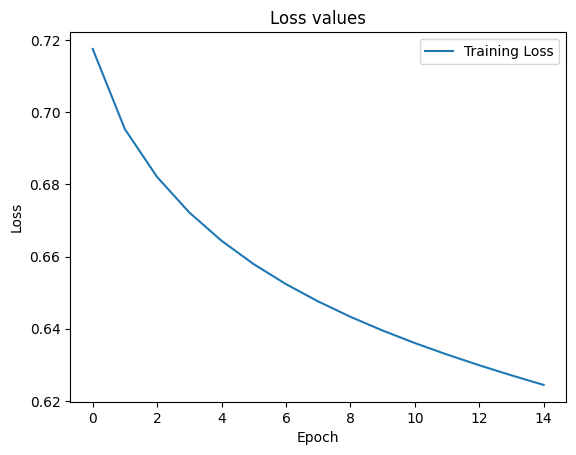

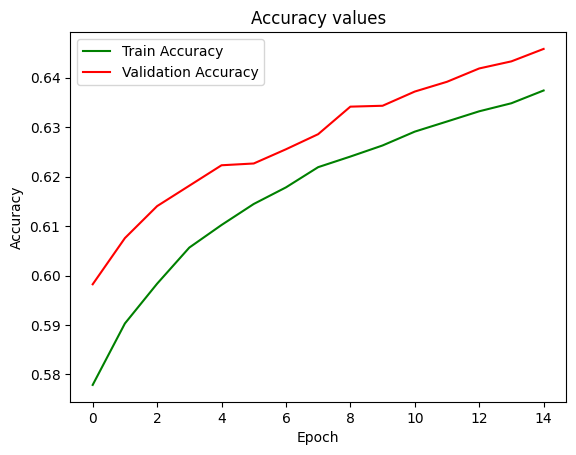

CPU times: user 8min 30s, sys: 748 ms, total: 8min 31s
Wall time: 8min 35s


In [ ]:
%%time
num_epochs = 10
train_losses, train_accs, val_accs = train_net(model, train_loader,
                                               val_loader, num_epochs=epochs,
                                               lr=learning_rate)

plot_losses(train_losses, train_accs, val_accs)

In [ ]:
print("Classification Accuracy on Validation set:", eval_accuracy(model, val_loader))

Recurrent Neural Networks (RNNs) are a class of neural networks designed for processing sequential data. Various types of RNN architectures have been developed to address different challenges, such as gradient vanishing and long-term dependency issues. Here are some of the key types:

**1. Vanilla RNN:**
The simplest form of RNNs that processes input sequences one element at a time and maintains a hidden state that captures the information of previous elements. Vanilla RNNs often struggle with long-term dependencies due to the vanishing gradient problem.
**2. Long Short-Term Memory (LSTM):**
LSTMs are an advanced RNN architecture designed to address the vanishing gradient problem. They introduce memory cells and gates (input, output, and forget gates) to regulate the flow of information, allowing the network to better capture long-term dependencies.
**3. Gated Recurrent Unit (GRU):**
GRUs are a variation of LSTMs that simplify the architecture by combining the input and forget gates into an update gate and merging the cell state with the hidden state. This simplification often leads to faster training times while still effectively capturing long-term dependencies.
**4. Bidirectional RNN:**
Bidirectional RNNs process data in both forward and backward directions (from the beginning to the end and vice versa). This approach allows the network to have both past and future context at each time step, improving the model's performance on tasks like sequence labeling and text classification.
**5. Attention-based RNN:**
Attention mechanisms allow RNNs to focus on different parts of the input sequence for each step of the output sequence, improving the model's ability to handle long sequences and complex dependencies. This approach is particularly effective in sequence-to-sequence tasks, such as machine translation.
**6. Echo State Network (ESN):**
ESNs are a type of RNN where the recurrent layer (called the "reservoir") is randomly generated and kept fixed during training. Only the output weights are trained, making ESNs much faster to train. ESNs are particularly useful for temporal data processing tasks.
**7. Peephole LSTM:**
Peephole LSTMs extend the traditional LSTM architecture by allowing the gate layers to also consider the cell state, not just the hidden state and the current input. This modification helps the model to better learn precise timing information, improving its performance on certain tasks.
Each of these RNN types has specific use cases and trade-offs, and the choice of which to use depends on the specific requirements and constraints of the task at hand.